In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPRegressor
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [2]:
def print_matrix(df):
    ''' Stampa la matrice di correlazione del dataframe.'''
    matrix = df.corr(numeric_only=True)
    plt.figure()
    sns.heatmap(matrix, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
    plt.show()

In [3]:
def prepare_features(df):
    df = df.copy()

    # 3. Feature temporali
    
    df["ANNO"] = df["ID_ORDER_DATE"].dt.year
    df["TRIMESTRE"] = df["ID_ORDER_DATE"].dt.quarter
    df["MESE"] = df["ID_ORDER_DATE"].dt.month
    df["MESE_SIN"] = np.sin(2 * np.pi * df["ID_ORDER_DATE"].dt.month / 12)
    df["MESE_COS"] = np.cos(2 * np.pi * df["ID_ORDER_DATE"].dt.month / 12)

    df["SETTIMANA"] = df["ID_ORDER_DATE"].dt.isocalendar().week.astype(int)
    df["GIORNO_SETTIMANA"] = df["ID_ORDER_DATE"].dt.weekday
    df["GIORNO_SETTIMANA_SIN"] = np.sin(2 * np.pi * df["ID_ORDER_DATE"].dt.weekday / 7)
    df["GIORNO_SETTIMANA_COS"] = np.cos(2 * np.pi * df["ID_ORDER_DATE"].dt.weekday / 7)
    df["WEEKEND"] = df["GIORNO_SETTIMANA"].isin([5,6]).astype(int)

    df["GIORNO"] = df["ID_ORDER_DATE"].dt.dayofyear
    df["GIORNO_SIN"] = np.sin(2 * np.pi * df["GIORNO"] / 365)
    df["GIORNO_COS"] = np.cos(2 * np.pi * df["GIORNO"] / 365)

    # 3. Lag features
    df["LAG_1"] = df["VAL_REVENUES"].shift(1)
    df["LAG_7"] = df["VAL_REVENUES"].shift(7)

    df = df.dropna().reset_index(drop=True)

    # 4. ordinamento
    df = df.sort_values("ID_ORDER_DATE")


    # 5. Rimozione date originali
    df = df.drop(columns=["ID_ORDER_DATE"], errors="ignore")
    
    return df

In [4]:
df = pd.read_csv("SALES_OLAP.csv")

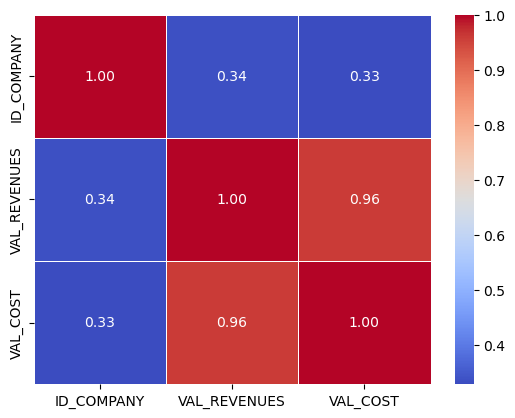

In [5]:
print_matrix(df)

In [6]:
df["ID_ORDER_DATE"] = pd.to_datetime(df["ID_ORDER_DATE"])
df_daily = (
        df.groupby(pd.Grouper(key="ID_ORDER_DATE", freq="D"))["VAL_REVENUES"]
          .sum()
          .reset_index()
    )

In [7]:
df_ml = prepare_features(df_daily)
df_ml

,VAL_REVENUES,ANNO,TRIMESTRE,MESE,MESE_SIN,MESE_COS,SETTIMANA,GIORNO_SETTIMANA,GIORNO_SETTIMANA_SIN,GIORNO_SETTIMANA_COS,WEEKEND,GIORNO,GIORNO_SIN,GIORNO_COS,LAG_1,LAG_7
0,0.0,2025,1,1,0.5,8.660254e-01,3,2,0.974928,-0.222521,0,15,0.255353,0.966848,61083.6,89828.40
1,38190.6,2025,1,1,0.5,8.660254e-01,3,3,0.433884,-0.900969,0,16,0.271958,0.962309,0.0,0.00
2,0.0,2025,1,1,0.5,8.660254e-01,3,4,-0.433884,-0.900969,0,17,0.288482,0.957485,38190.6,55548.10
3,0.0,2025,1,1,0.5,8.660254e-01,3,5,-0.974928,-0.222521,1,18,0.304921,0.952378,0.0,0.00
4,0.0,2025,1,1,0.5,8.660254e-01,3,6,-0.781831,0.623490,1,19,0.321270,0.946988,0.0,0.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
424,0.0,2026,1,3,1.0,6.123234e-17,11,6,-0.781831,0.623490,1,74,0.956235,0.292600,0.0,0.00
425,0.0,2026,1,3,1.0,6.123234e-17,12,0,0.000000,1.000000,0,75,0.961130,0.276097,0.0,47678.00
426,0.0,2026,1,3,1.0,6.123234e-17,12,1,0.781831,0.623490,0,76,0.965740,0.259512,0.0,22793.28
427,0.0,2026,1,3,1.0,6.123234e-17,12,2,0.974928,-0.222521,0,77,0.970064,0.242850,0.0,0.00


In [8]:
split_idx = int(len(df_ml) * 0.8)

train = df_ml.iloc[:split_idx]
test = df_ml.iloc[split_idx:]

x_train = train.drop(columns=["VAL_REVENUES"])
y_train = train["VAL_REVENUES"]

x_test = test.drop(columns=["VAL_REVENUES"])
y_test = test["VAL_REVENUES"]

# --- log-transform target ---
y_train = np.log1p(y_train)
y_test = np.log1p(y_test)


tscv = TimeSeriesSplit(n_splits=3)

In [9]:
pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("mlp", MLPRegressor(random_state=42))
])

tscv = TimeSeriesSplit(n_splits=3)
# 4. Grid Search
param_grid = {
    "mlp__max_iter": [500, 800, 1200],
    "mlp__hidden_layer_sizes": [(64,), (128,), (128, 64), (128, 64, 32)],
    "mlp__activation": ["relu", "tanh"],
    "mlp__learning_rate_init": [0.001, 0.0005],
    "mlp__alpha": [0.0001, 0.001],
}

grid = GridSearchCV(
    pipeline,
    param_grid,
    cv=tscv,
    scoring="neg_mean_absolute_error",
    n_jobs=-1
)

grid.fit(x_train, y_train)

print("Migliori parametri:", grid.best_params_)
print("MAE CV:", -grid.best_score_)

# 5. Valutazione sul test
best_model = grid.best_estimator_
y_pred = best_model.predict(x_test)

print("MAE test:", mean_absolute_error(y_test, y_pred))
print("RMSE test:", np.sqrt(mean_squared_error(y_test, y_pred)))
print("R2 test:", r2_score(y_test, y_pred))

Migliori parametri: {'mlp__activation': 'relu', 'mlp__alpha': 0.0001, 'mlp__hidden_layer_sizes': (64,), 'mlp__learning_rate_init': 0.0005, 'mlp__max_iter': 500}
MAE CV: 4.557098746426964
MAE test: 3.8448262489709792
RMSE test: 4.708693608812362
R2 test: 0.0831017571804149


C:\Users\patrizio\anaconda3\envs\esercizio\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(
